# Protein structure of an omics target — fetch, visualize, and *assess before you trust*

`ov.mol` is the bridge from an omics result to molecular structure. A typical
omicverse analysis ends with a **target** — a differential gene from `ov.bulk`,
a marker from `ov.single`, a variant from `ov.genetics`. This tutorial takes
one such target and answers the first structural question: *what does it look
like in 3D?*

But a predicted structure is **not** a fact — it is a hypothesis with a
per-residue confidence map. The single most common mistake is to analyse a
predicted model uniformly. So this tutorial follows the EBI / AlphaFold-team
**model-confidence interpretation workflow**: *check pLDDT and PAE first*, then
decide which regions are safe to interpret.

**The target.** We use **EGFR** (epidermal growth factor receptor) — a
canonical druggable oncogene — as if it had just been handed over by an
upstream differential-expression analysis.

**What you will do**

1. Fetch the structure (AlphaFold DB)
2. Assess **pLDDT** — per-residue confidence — with the interactive 3D viewer
3. Assess **PAE** — inter-domain confidence
4. Identify the well-folded domain suitable for drug work
5. Paint **variant positions** onto the structure (the omics bridge)
6. Predict a **mutant** structure absent from AlphaFold DB (ESMFold)

> Requires `pip install 'omicverse[mol]'`. The 3D views are **py3Dmol** — they
> render inline *and* persist in the exported HTML docs.

> **Rendering note.** Inline 3D views below use **py3Dmol**, which
> emits an HTML/JavaScript block. JupyterLab applies a *trust filter*
> that strips scripts from any notebook it has not signed with your
> local key — so a notebook you cloned from the repo, or one that was
> executed by `nbconvert`, opens *untrusted* and the views show only the
> "3Dmol.js failed to load" warning even though the HTML *is* saved in
> the file. To restore the interactive 3D views, either re-execute the
> cells in your own kernel (auto-trusts the current session) or run
> `jupyter trust /path/to/this/notebook.ipynb` in a terminal. The
> mkdocs-rendered version of this tutorial is static HTML, so the views
> work without trust there.

## 0. Setup

In [1]:
import omicverse as ov
import numpy as np
import matplotlib.pyplot as plt
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Fetch the target structure

`fetch_structure` accepts a gene symbol, a UniProt accession or a PDB ID. Given
a gene symbol it resolves gene → UniProt, then pulls the **AlphaFold DB**
predicted model — which covers essentially every human protein, so any omics
target has a structure to start from.

The returned `MolStructure` carries the parsed atoms, the one-letter sequence,
and — crucially for a predicted model — the **pLDDT** confidence array and the
**PAE** matrix.

In [2]:
s = ov.mol.fetch_structure('EGFR', verbose=True)
s

resolved gene EGFR -> UniProt P00533


fetched AlphaFold model AF-P00533-F1 (v6)


MolStructure(EGFR, source=alphafold, 1210 residues, mean pLDDT 75.9)

In [3]:
print(f'source        : {s.source}')
print(f'UniProt        : {s.uniprot}   gene: {s.gene}')
print(f'residues       : {s.n_residues}')
print(f'mean pLDDT     : {np.mean(s.plddt):.1f}')
print(f'PAE matrix     : {s.pae.shape}')

source        : alphafold
UniProt        : P00533   gene: EGFR
residues       : 1210
mean pLDDT     : 75.9
PAE matrix     : (1210, 1210)


## 2. pLDDT — per-residue confidence

**pLDDT** is AlphaFold's per-residue self-confidence (0–100). The AlphaFold
team defines four bands:

| Band | pLDDT | Interpretation |
|---|---|---|
| Very high | > 90 | backbone **and** side chains reliable |
| High | 70–90 | backbone reliable |
| Low | 50–70 | treat with caution |
| Very low | < 50 | likely disordered — *not* a folding failure, but a real prediction of disorder |

Colour the structure by pLDDT — blue = confident, orange = unreliable. The view
below is **interactive**: drag to rotate, scroll to zoom.

In [4]:
v = ov.mol.view(s, color_by='pLDDT', width=720, height=520)
v

ov.mol.view: pLDDT confidence bands (blue high -> orange low)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Quantify how much of the model falls in each band — this tells you, up
front, how much of the protein you can actually interpret.

In [5]:
p = s.plddt
bands = {'Very high (>90)': p > 90, 'High (70-90)': (p > 70) & (p <= 90),
         'Low (50-70)': (p > 50) & (p <= 70), 'Very low (<=50)': p <= 50}
for name, mask in bands.items():
    print(f'{name:18s}: {100 * mask.mean():5.1f}%  ({mask.sum()} residues)')

Very high (>90)   :  47.2%  (571 residues)
High (70-90)      :  23.5%  (284 residues)
Low (50-70)       :   6.5%  (79 residues)
Very low (<=50)   :  22.8%  (276 residues)


EGFR is a large multi-domain receptor. A substantial low / very-low
pLDDT fraction is **expected** — it is the flexible inter-domain linkers and
the disordered C-terminal tail, not a broken model. The folded domains
themselves score high.

## 3. PAE — is the *domain arrangement* trustworthy?

pLDDT is **local**. It does not tell you whether two confidently-folded domains
are placed correctly *relative to each other*. That is what **PAE** (Predicted
Aligned Error) answers: PAE[i, j] is the expected error in residue *i* when the
model is aligned on residue *j*.

- **Low PAE** block on the diagonal → a well-defined domain.
- **High PAE** between two diagonal blocks → the two domains are each
  confident, but their *relative orientation* is uncertain.

The practical rule: **structure-based drug work must stay within a single
low-PAE domain** — never reason across a high-PAE inter-domain boundary.

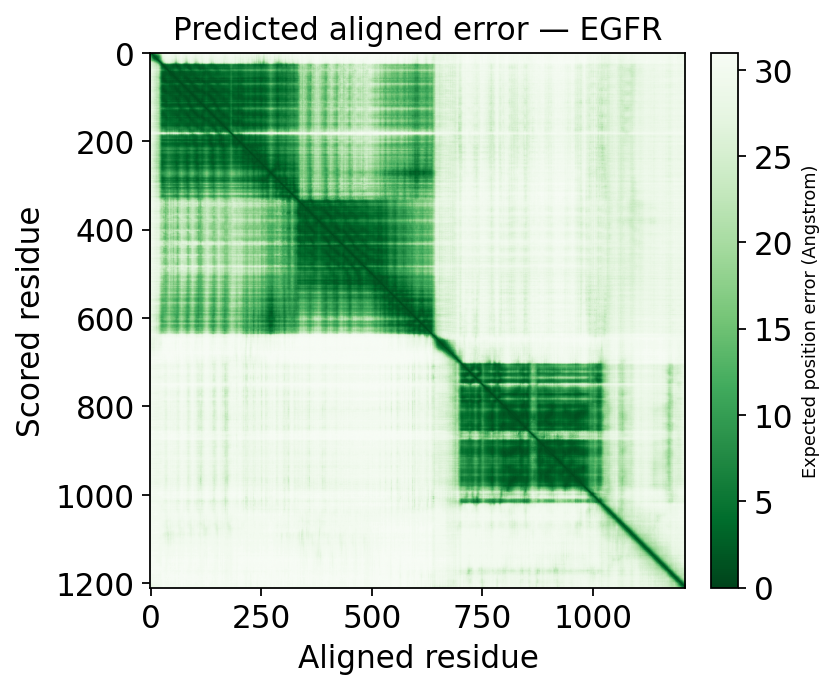

In [6]:
ax = ov.mol.plot_pae(s)
plt.show()

The dark low-PAE blocks on the diagonal are EGFR's individual domains.
The bright off-diagonal regions are the inter-domain pairs whose relative
arrangement AlphaFold is **not** confident about — exactly the boundaries not
to reason across.

## 4. The well-folded domain for drug work

EGFR's intracellular **tyrosine-kinase domain** (UniProt residues ~712–979) is
the drug target — every approved EGFR small-molecule inhibitor binds its ATP
pocket. Confirm it is a high-confidence, well-folded region before doing any
structural drug work on it.

In [7]:
rid = s.residue_ids
kinase = (rid >= 712) & (rid <= 979)
print(f'kinase domain (712-979): mean pLDDT {s.plddt[kinase].mean():.1f}'
      f'  over {kinase.sum()} residues')
print(f'rest of the protein     : mean pLDDT {s.plddt[~kinase].mean():.1f}')

kinase domain (712-979): mean pLDDT 84.1  over 268 residues
rest of the protein     : mean pLDDT 73.6


View just the kinase domain, coloured by confidence — this is the region
the druggability and docking tutorials build on.

In [8]:
kin_residues = [int(r) for r in rid[kinase]]
v = ov.mol.view(s, color_by='pLDDT', highlight=None, width=720, height=520)
v

ov.mol.view: pLDDT confidence bands (blue high -> orange low)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 5. The omics bridge — paint variant positions

This is where `ov.mol` earns its place in omicverse: a per-residue omics
signal — variant calls from `ov.genetics`, a conservation track, a
mutation-burden score — can be painted directly onto the 3D model.

EGFR has well-known oncogenic driver mutations. We highlight three canonical
ones (UniProt / precursor numbering): **G719S**, **T790M** ("gatekeeper"
resistance) and **L858R** (the most common activating mutation). `highlight`
draws them as sticks on the cartoon.

In [9]:
variants = [719, 790, 858]
for pos in variants:
    i = int(np.where(rid == pos)[0][0])
    print(f'residue {pos} ({s.sequence[i]}): pLDDT {s.plddt[i]:.1f}')

residue 719 (G): pLDDT 73.3
residue 790 (T): pLDDT 88.4
residue 858 (L): pLDDT 51.2


Read the confidence at each variant **before** interpreting it:

- **G719** (pLDDT ≈ 73) and **T790** (≈ 88) sit in well-folded, high-confidence
  regions — structural reasoning about those mutations stands on solid ground.
- **L858** scores pLDDT ≈ 51 — the *low* band. This is **not** a model
  failure: L858 lies in the kinase **activation loop**, a genuinely flexible
  element, and AlphaFold correctly reports low confidence there.

That is the workflow paying off: the same mutation list, but the model only
supports confident structural claims for two of the three positions — for
L858R, a rigid-structure argument must be made with caution. Now see where
they fall in 3D:

In [10]:
v = ov.mol.view(s, color_by='pLDDT', highlight=variants,
                width=720, height=520)
v

ov.mol.view: pLDDT confidence bands (blue high -> orange low)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The three highlighted residues cluster around the ATP-binding cleft —
which is *why* they alter drug binding and drive resistance. The structure
turns a flat list of variant positions into a mechanistic picture.

## 6. Predict a structure absent from AlphaFold DB

AlphaFold DB stores the **wild-type** sequence. To see the *mutant* — or any
sequence not in the database (a non-model species, a designed construct) — you
must fold it yourself. `predict_structure` calls the **ESMFold** remote API:
sequence → 3D, no MSA, no local GPU.

We build the **L858R** mutant of the EGFR kinase domain and fold it.

In [11]:
kin_seq = ''.join(c for r, c in zip(rid, s.sequence) if 712 <= r <= 979)
i858 = 858 - 712
mut_seq = kin_seq[:i858] + 'R' + kin_seq[i858 + 1:]
print(f'kinase domain: {len(kin_seq)} residues; '
      f'position 858 {kin_seq[i858]} -> {mut_seq[i858]}')

kinase domain: 268 residues; position 858 L -> R


In [12]:
mut = ov.mol.predict_structure(mut_seq, name='EGFR_L858R_kinase',
                               verbose=True)
print(f'{mut!r}  | mean pLDDT {np.mean(mut.plddt):.1f}')

MolStructure(?, source=esmfold, 268 residues, mean pLDDT 89.2)  | mean pLDDT 89.2


View the ESMFold-predicted mutant kinase domain, coloured by its own
pLDDT. ESMFold reports confidence on the same 0–100 scale, so the four-band
reading from step 2 applies identically.

In [13]:
v = ov.mol.view(mut, color_by='pLDDT', width=720, height=520)
v

ov.mol.view: pLDDT confidence bands (blue high -> orange low)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Interpretation

- A predicted structure is a **hypothesis with a per-residue confidence map** —
  `pLDDT` (local) *and* `PAE` (inter-domain). Always read both before
  interpreting a model.
- Restrict structural drug work to a **confident, low-PAE domain** — for EGFR,
  the kinase domain.
- The omics bridge — `view(highlight=...)`, `view(color_by=<score>)` — only
  carries meaning where the model is confident.
- For sequences absent from AlphaFold DB (mutants, designed constructs),
  `predict_structure` folds them on demand via ESMFold.

**Next:** the [druggability tutorial](t_mol_druggability.ipynb) detects the
binding pockets of this kinase domain and asks whether the target is
druggable.